In [1]:
# Plotting country boarders from country mask

In [8]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter

In [4]:
# === Path config ===
MASK_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"

In [10]:
mask_file = "GBD_Country_Masks_0.10.nc"
mask_path = os.path.join(MASK_DIR, mask_file)
masks = xr.open_dataarray(mask_path)

In [11]:
# Create DataArray filled with NaNs
global_array = xr.DataArray(
    np.full((len(masks.lat), len(masks.lon)), np.nan),
    coords={"lat": masks.lat.values, "lon": masks.lon.values},
    dims=["lat", "lon"]
)

In [14]:
# Loop over countries, number the country and apply to empty array
# using the country mask
for i in range(len(masks.country)):
    mask = masks.isel(country=i)
    country = masks.isel(country=i)["country"]
    country_number = i
    global_array = global_array.where(mask == 0, country_number)

In [32]:
# === Path config ===
OBS_DIR = "/glade/work/awells/air_quality/O3_obs/"

obs_file = "Delang_BME_OSDMA8_1990_2017.nc"
obs_path = os.path.join(OBS_DIR, obs_file)
obs = xr.open_dataset(obs_path)["ozone"]

obs_lat_max = obs.latitude.max()
obs_lat_min = obs.latitude.min()

masked_array = global_array.where(global_array['lat'] >= obs_lat_max)

In [46]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataarray(pop_path)

masked_pop = population.where(population['lat'] >= obs_lat_max).mean("year")

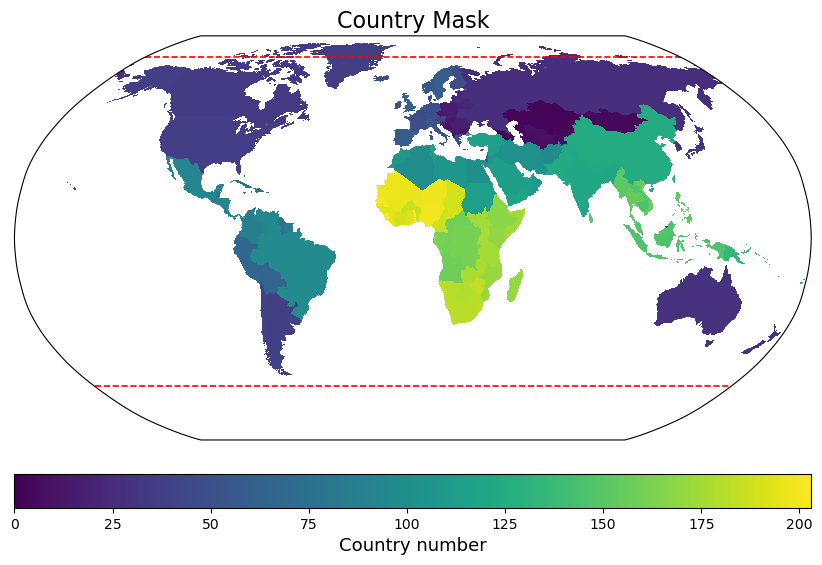

In [37]:
# Create figure
fig = plt.figure(figsize=autosize_figure(1, 1))
gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(global_array).plot(
    transform=crs,
    add_colorbar=False,
    subplot_kws={'projection': projection}
)
#ax.coastlines(resolution="50m", linewidth=0.75)
#ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("Country Mask", fontsize=16)

# Plot latitude extent
lons = np.linspace(-180, 180, 1000)  # longitudes from -180 to 180
lats = np.full_like(lons, obs_lat_max)  # constant latitude
ax.plot(lons, lats, transform=crs, color='red', linewidth=1.2, linestyle='--')

lats = np.full_like(lons, obs_lat_min)  # constant latitude
ax.plot(lons, lats, transform=crs, color='red', linewidth=1.2, linestyle='--')

# First colorbar
cax = fig.add_subplot(gs[1, 0])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label("Country number", fontsize=13)

plt.tight_layout()


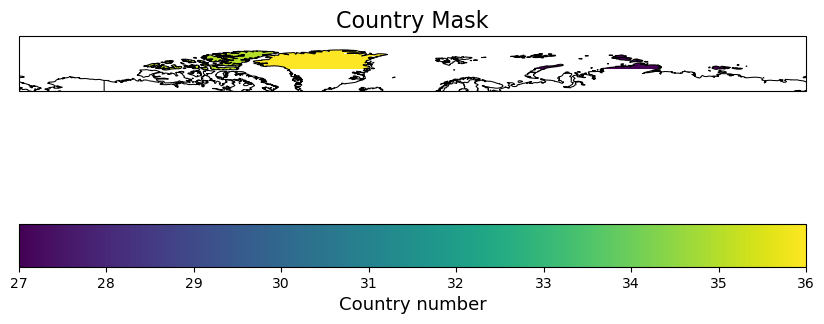

In [42]:
# Create figure
fig = plt.figure(figsize=autosize_figure(1, 1))
gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

projection = ccrs.PlateCarree()
crs = ccrs.PlateCarree()

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(masked_array).plot(
    transform=crs,
    add_colorbar=False,
    subplot_kws={'projection': projection}
)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("Country Mask", fontsize=16)

ax.set_extent([-180, 180, obs_lat_max-10, 90], crs=crs)

# First colorbar
cax = fig.add_subplot(gs[1, 0])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label("Country number", fontsize=13)

plt.tight_layout()


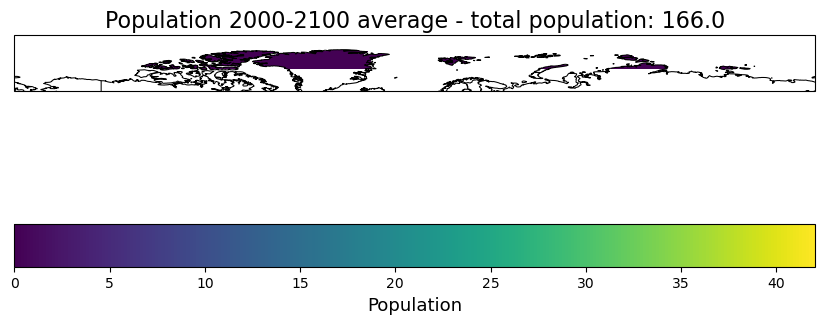

In [53]:
# Create figure
fig = plt.figure(figsize=autosize_figure(1, 1))
gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

projection = ccrs.PlateCarree()
crs = ccrs.PlateCarree()

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(masked_pop).plot(
    transform=crs,
    add_colorbar=False,
    subplot_kws={'projection': projection}
)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title(f"Population 2000-2100 average - total population: {masked_pop.sum().values.round()}", fontsize=16)

ax.set_extent([-180, 180, obs_lat_max-10, 90], crs=crs)

# First colorbar
cax = fig.add_subplot(gs[1, 0])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label("Population", fontsize=13)

plt.tight_layout()
